# Token Approximation — EDA, Existing Methods, and Baselines

Concise analysis and baseline models to approximate input token counts from local text features.

Technical depth (ablations, diagnostics, learning curves) is in `02_appendix_diagnostics.ipynb`.

## Overview and Hypothesis

- Hypothesis: Local text features (bytes, runes, words, lines) can approximate provider language model input token counts.
- Why it matters: Enables local budgeting without remote tokenizers, helpful for throughput, cost, and context management.
- Approach: (1) Evaluate existing off-the-shelf token approximation methods; (2) Fit simple regression baselines; (3) Compare everything on a shared held-out test set.
- Scope: Token counts are tokenizer- and language model-specific; external validity may vary.
- Terminology: “runes” = Unicode code points; features used: bytes, runes, words, lines.

## Data

- Data source (ground truth): `data/processed/datasets/dataset.jsonl` produced by the `token-approx measure` tool over sample texts.
- Columns: `bytes`, `runes` (Unicode code points), `words`, `lines`, `input_tokens`, `model`, `source_path`.
- Existing methods (no training), evaluated on the same samples:
  - `preds_heuristic.jsonl` — Anthropic 3.5 runes-per-token heuristic.
  - `preds_anth-ts.jsonl` — old Anthropic TypeScript tokenizer.
  - `preds_tiktoken.jsonl` — OpenAI `tiktoken` (`cl100k_base`).


### Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import sys
from IPython.display import display, Markdown
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Locate repo root
cur = Path.cwd().resolve()
repo_root = cur
for parent in [cur] + list(cur.parents):
    if (parent / "go.mod").exists() or (parent / "go.sum").exists():
        repo_root = parent
        break
# Add the shared utils.py dir to Python import path
utils_dir = repo_root / "notebooks"
if str(utils_dir) not in sys.path:
    sys.path.append(str(utils_dir))

from utils import (
    SEED as SEED_DEFAULT, N_GRID_DEFAULT, MAPE_THRESHOLD_DEFAULT, DECISION_MARGIN_DEFAULT,
    CV_SPLITS_A_DEFAULT, CV_SPLITS_DEFAULT, CV_REPEATS_DEFAULT, BOOT_B_DEFAULT, FEATURES,
    load_ground_truth, load_method_preds, join_preds_to_ground_truth, corr_heatmap, cv_single_feature, select_best,
    fit_single_feature, approach_b_ridge_cv, approach_b_elasticnet_cv, summarize_and_decide,
    repeated_cv_mae, bootstrap_mae_ci, export_single_feature, export_linear_multifeature,
    coef_sanity_checks, best_subset_ols, abs_error_stats, plot_abs_error_hist,
    mape_filtered, scatter_grid_regplot, resolve_chosen_predictions, evaluate_method_on_split,
    build_comparison_table,
)

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)


### Configuration

In [2]:
# Defaults can be overridden as needed
SEED = SEED_DEFAULT  # random seed for splits/CV
N_GRID = N_GRID_DEFAULT  # learning-curve grid (used in appendix)
MAPE_THRESHOLD = MAPE_THRESHOLD_DEFAULT  # floor for computing MAPE
DECISION_MARGIN = DECISION_MARGIN_DEFAULT  # min relative MAE gain to pick B over A
CV_SPLITS_A = CV_SPLITS_A_DEFAULT  # folds for A-selection CV
CV_SPLITS = CV_SPLITS_DEFAULT  # folds for stability CV + learning curves
CV_REPEATS = CV_REPEATS_DEFAULT  # repeats for stability CV
BOOT_B = BOOT_B_DEFAULT  # bootstrap resamples
MODEL_NAME = "claude-3-7-sonnet-latest"  # tokenizer/model scope for ground truth

display(Markdown(
    f"""Constants set for this run:\
- `SEED`=`{SEED}`\n- `DECISION_MARGIN`=`{DECISION_MARGIN}`\n- `MAPE_THRESHOLD`=`{MAPE_THRESHOLD}`\n- `CV_SPLITS` x `CV_REPEATS`=`{CV_SPLITS}` x `{CV_REPEATS}`\n"""
))


Constants set for this run:- `SEED`=`42`
- `DECISION_MARGIN`=`0.03`
- `MAPE_THRESHOLD`=`50`
- `CV_SPLITS` x `CV_REPEATS`=`10` x `5`


### Load and Validate Data (Ground Truth)

In [3]:
dataset_path = Path('..') / 'data' / 'processed' / 'datasets' / 'dataset.jsonl'
print({'dataset_path': str(dataset_path)})

# Ground-truth records (token counts + local features)
df = load_ground_truth(dataset_path)
print(df.attrs.get('validation_info', {}))
df.head()


{'dataset_path': '../data/processed/datasets/dataset.jsonl'}
{'total_before': 37, 'drops': {'input_tokens_na': 0, 'bytes_non_numeric_or_na': 0, 'runes_non_numeric_or_na': 0, 'words_non_numeric_or_na': 0, 'lines_non_numeric_or_na': 0}, 'total_after': 37}


,bytes,runes,words,lines,input_tokens,model,source_path
0,37786,35724,5924,735,12797,claude-3-7-sonnet-latest,data/processed/samples/les-trois-mousquetaires...
1,37886,35920,6042,692,12401,claude-3-7-sonnet-latest,data/processed/samples/les-trois-mousquetaires...
2,38114,35996,6099,779,12863,claude-3-7-sonnet-latest,data/processed/samples/les-trois-mousquetaires...
3,37882,35887,6157,810,12813,claude-3-7-sonnet-latest,data/processed/samples/les-trois-mousquetaires...
4,37923,35974,6160,738,12733,claude-3-7-sonnet-latest,data/processed/samples/les-trois-mousquetaires...


## Exploratory Visuals

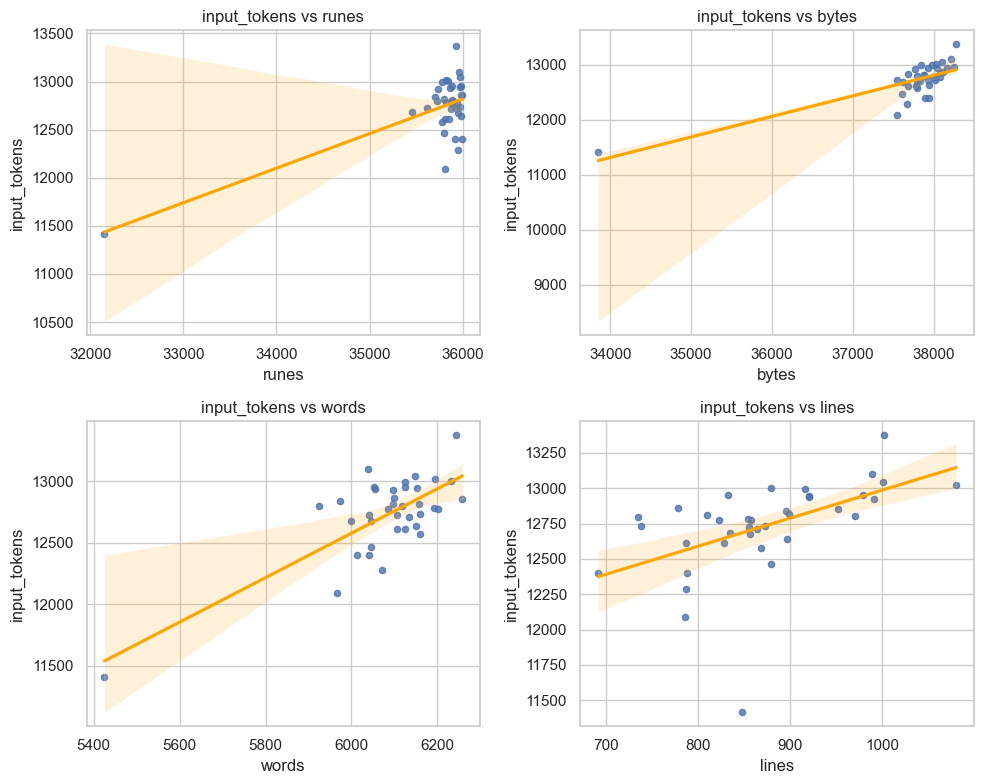

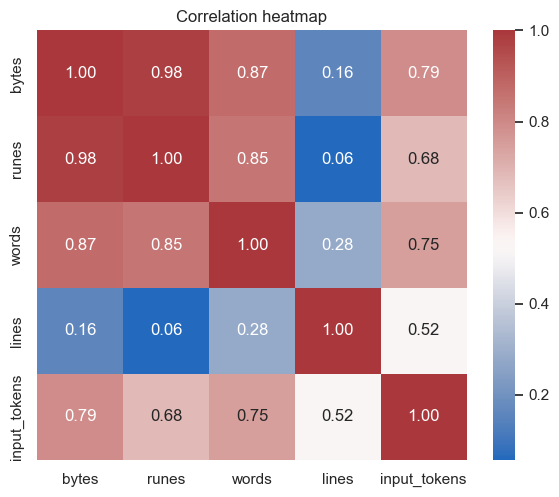

In [4]:
sns.set_theme(style='whitegrid')

pairs = [
    ('runes', 'input_tokens'),
    ('bytes', 'input_tokens'),
    ('words', 'input_tokens'),
    ('lines', 'input_tokens'),
]
_ = scatter_grid_regplot(
    df,
    pairs=pairs,
    figsize=(10, 8),
    scatter_kws={'s': 20, 'alpha': 0.8},
    line_kws={'color': 'orange'},
)

ax = corr_heatmap(df)


## Section 1 – Existing Methods (No Training)

In this section we evaluate three existing methods used in practice today for approximating token counts, all on the same held-out test split and with the same metrics as the learned models later on:

- Heuristic: 3.5 runes per token (Anthropic recommendation).
- Old Anthropic TypeScript tokenizer.
- OpenAI `tiktoken` tokenizer (`cl100k_base`).

All are fixed mappings; there is no training. We only measure how well they approximate the ground-truth token counts from Anthropic's Token Count API.


### 1.1 Load Predictions and Define Shared Train/Test Split

In [5]:
# Prediction files for existing methods
preds_dir = Path('..') / 'data' / 'processed' / 'datasets'
heuristic_path = preds_dir / 'preds_heuristic.jsonl'
anth_ts_path = preds_dir / 'preds_anth-ts.jsonl'
tiktoken_path = preds_dir / 'preds_tiktoken.jsonl'

preds_heuristic = load_method_preds(heuristic_path)
preds_anth_ts = load_method_preds(anth_ts_path)
preds_tiktoken = load_method_preds(tiktoken_path)

# One shared train/test split on the ground-truth dataset
train_df, test_df = train_test_split(df, test_size=0.2, random_state=SEED)
print({'n_train': len(train_df), 'n_test': len(test_df)})

# Helper: index sets by source_path so the same split can be applied after joining preds
train_sources = set(train_df['source_path'])
test_sources = set(test_df['source_path'])
assert train_sources.isdisjoint(test_sources)
assert train_sources.union(test_sources) == set(df['source_path'])


{'n_train': 29, 'n_test': 8}


### 1.2 Join Each Method's Predictions to Ground Truth

We join each method's predictions to the ground-truth records by `source_path`. For each method we then re-use the same train/test split by matching `source_path` membership.

In [6]:
# Join helper: returns train/test DataFrames with a 'pred_tokens' column for the method
def make_method_split(df_gt, preds_df):
    joined = join_preds_to_ground_truth(df_gt, preds_df, pred_col='pred_tokens')
    train_j = joined[joined['source_path'].isin(train_sources)].copy()
    test_j = joined[joined['source_path'].isin(test_sources)].copy()
    return train_j, test_j

train_heuristic, test_heuristic = make_method_split(df, preds_heuristic)
train_anth_ts, test_anth_ts = make_method_split(df, preds_anth_ts)
train_tiktoken, test_tiktoken = make_method_split(df, preds_tiktoken)

print({
    'heuristic_n_test': len(test_heuristic),
    'anth-ts_n_test': len(test_anth_ts),
    'tiktoken_n_test': len(test_tiktoken),
})


{'heuristic_n_test': 8, 'anth-ts_n_test': 8, 'tiktoken_n_test': 8}


### 1.3 Per-Method Evaluation (Existing Methods)

**Metrics**

- `test_mae` — mean absolute error in tokens.
- `test_mbe` (mean bias error) = `mean(y_true − y_pred)`; positive ⇒ under‑prediction on average, negative ⇒ over‑prediction.
- `mape_filtered_pct` — MAPE on samples with `y_true ≥ MAPE_THRESHOLD`.
- `abs_err_median`, `abs_err_p95`, `abs_err_max` — distribution of absolute errors.

#### Heuristic - 3.5 runes per token

,method_id,stage,test_mae,test_mbe,mape_filtered,mape_filtered_pct,abs_err_median,abs_err_p95,abs_err_max,n
0,heuristic_3.5-runes-per-token,existing_test,2548.125,2548.125,0.198688,19.868814,2548.5,2971.528571,3108.428571,8


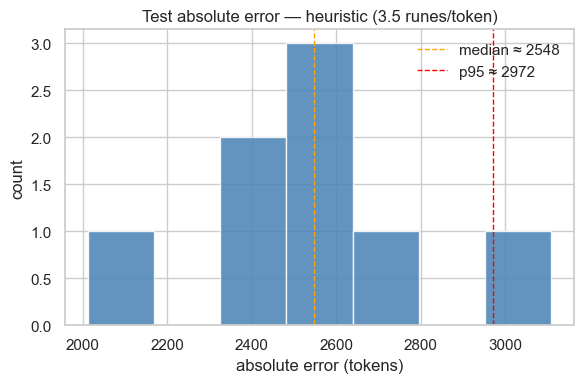

#### Old Anthropic TS tokenizer

,method_id,stage,test_mae,test_mbe,mape_filtered,mape_filtered_pct,abs_err_median,abs_err_p95,abs_err_max,n
0,anth-ts_default,existing_test,231.75,231.75,0.018097,1.809651,241.0,339.85,350.0,8


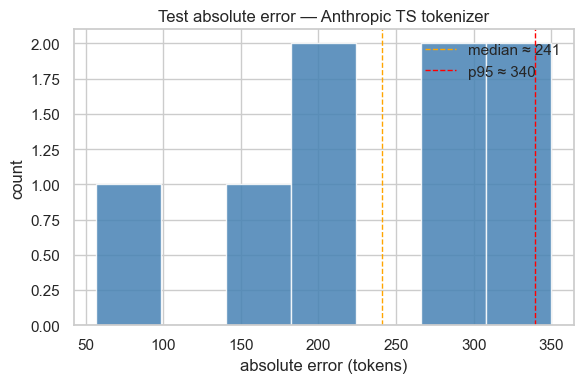

#### OpenAI tiktoken tokenizer (`cl100k_base`)

,method_id,stage,test_mae,test_mbe,mape_filtered,mape_filtered_pct,abs_err_median,abs_err_p95,abs_err_max,n
0,tiktoken_cl100k_base,existing_test,1499.625,1499.625,0.117066,11.706587,1527.0,1627.15,1645.0,8


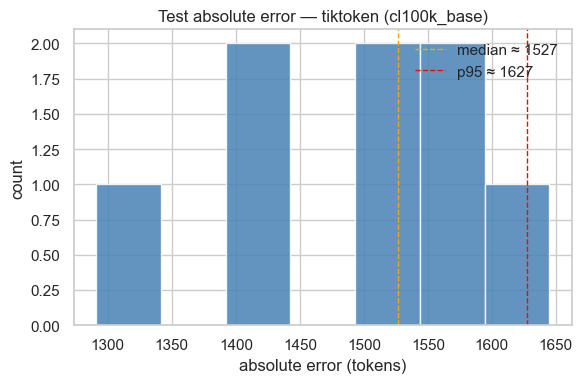

In [7]:
existing_rows = []
existing_details = {}  # hold (y_true, y_pred) for optional plots

# 1.3.1 Heuristic – 3.5 runes per token
res_heuristic = evaluate_method_on_split(
    df_train=train_heuristic,
    df_test=test_heuristic,
    pred_col='pred_tokens',
    method_id='heuristic_3.5-runes-per-token',
    mape_threshold=MAPE_THRESHOLD,
)
display(Markdown('#### Heuristic - 3.5 runes per token'))
display(pd.DataFrame([res_heuristic]))
existing_rows.append({
    'family': 'existing',
    **res_heuristic,
})
existing_details['heuristic'] = (
    test_heuristic['input_tokens'].to_numpy(),
    test_heuristic['pred_tokens'].to_numpy(),
)
_ = plot_abs_error_hist(
    *existing_details['heuristic'],
    bins=max(3, min(7, len(test_heuristic))),
    title='Test absolute error — heuristic (3.5 runes/token)',
    show_refs=True,
)

# 1.3.2 Old Anthropic TS tokenizer
res_anth_ts = evaluate_method_on_split(
    df_train=train_anth_ts,
    df_test=test_anth_ts,
    pred_col='pred_tokens',
    method_id='anth-ts_default',
    mape_threshold=MAPE_THRESHOLD,
)
display(Markdown('#### Old Anthropic TS tokenizer'))
display(pd.DataFrame([res_anth_ts]))
existing_rows.append({
    'family': 'existing',
    **res_anth_ts,
})
existing_details['anth-ts'] = (
    test_anth_ts['input_tokens'].to_numpy(),
    test_anth_ts['pred_tokens'].to_numpy(),
)
_ = plot_abs_error_hist(
    *existing_details['anth-ts'],
    bins=max(3, min(7, len(test_anth_ts))),
    title='Test absolute error — Anthropic TS tokenizer',
    show_refs=True,
)

# 1.3.3 OpenAI tiktoken tokenizer
res_tiktoken = evaluate_method_on_split(
    df_train=train_tiktoken,
    df_test=test_tiktoken,
    pred_col='pred_tokens',
    method_id='tiktoken_cl100k_base',
    mape_threshold=MAPE_THRESHOLD,
)
display(Markdown('#### OpenAI tiktoken tokenizer (`cl100k_base`)'))
display(pd.DataFrame([res_tiktoken]))
existing_rows.append({
    'family': 'existing',
    **res_tiktoken,
})
existing_details['tiktoken'] = (
    test_tiktoken['input_tokens'].to_numpy(),
    test_tiktoken['pred_tokens'].to_numpy(),
)
_ = plot_abs_error_hist(
    *existing_details['tiktoken'],
    bins=max(3, min(7, len(test_tiktoken))),
    title='Test absolute error — tiktoken (cl100k_base)',
    show_refs=True,
)


### 1.4 Section 1 Summary Table and Takeaways

In [8]:
existing_table = build_comparison_table(existing_rows)
display(Markdown('#### Existing methods — test performance comparison'))
display(existing_table)

best_existing_mae = float(existing_table['test_mae'].min()) if not existing_table.empty else np.nan


#### Existing methods — test performance comparison

,family,method_id,stage,test_mae,test_mbe,mape_filtered_pct,abs_err_median,abs_err_p95,abs_err_max,n
1,existing,anth-ts_default,existing_test,231.750,231.750,1.809651,241.0,339.850000,350.000000,8
2,existing,tiktoken_cl100k_base,existing_test,1499.625,1499.625,11.706587,1527.0,1627.150000,1645.000000,8
0,existing,heuristic_3.5-runes-per-token,existing_test,2548.125,2548.125,19.868814,2548.5,2971.528571,3108.428571,8


## Section 2 – New Model-Based Methods (Approach A & B)

We now fit simple regression models from local features to approximate token counts.

- **Approach A**: single-feature linear model with CV over feature + intercept.
- **Approach B**: multi-feature linear models (OLS best subset, Ridge, ElasticNet).

All models are trained on the same `train_df` defined earlier and evaluated on the same `test_df` used for existing methods.

### 2.1 Approach A – Single-Feature Linear Regression: CV Selection

Approach A deliberately keeps things simple: one feature (e.g. bytes) and a straight line fit. We use cross-validation mainly to choose between features and whether to include an intercept.

In [9]:
# CV across single features and intercept options (on train_df)
features_list = FEATURES
rows_a = []
for feat in features_list:
    Xtr_feat = train_df[[feat]].to_numpy()
    ytr = train_df['input_tokens'].to_numpy()
    for fi in (False, True):
        mae_cv, bias_cv = cv_single_feature(
            Xtr_feat, ytr,
            fit_intercept=fi,
            n_splits=CV_SPLITS_A,
            seed=SEED,
        )
        rows_a.append({'feature': feat, 'fit_intercept': fi, 'cv_mae': mae_cv, 'cv_bias': bias_cv})
cv_results = pd.DataFrame(rows_a).sort_values(['cv_mae', 'feature', 'fit_intercept']).reset_index(drop=True)

best_cv = select_best(cv_results)
res_a = fit_single_feature(train_df, test_df, feature=best_cv['feature'], fit_intercept=bool(best_cv['fit_intercept']))

display(Markdown('#### CV results (train) (Approach A)'))
display(cv_results)

y_true_sf = res_a['yte']
y_pred_sf = res_a['pred']
mape_a = mape_filtered(y_true_sf, y_pred_sf, threshold=MAPE_THRESHOLD)

display(Markdown('#### Held-out Test Results (Approach A)'))
display(pd.DataFrame([{
    'stage': 'A_single_feature_test',
    'feature': res_a['feature'],
    'fit_intercept': res_a['fit_intercept'],
    'test_mae': res_a['test_mae'],
    'test_mbe': res_a['test_mbe'],
    'MAPE_after_filter': mape_a,
    'MAPE_after_filter_pct': None if mape_a is None else 100*mape_a,
}]))


#### CV results (train) (Approach A)

,feature,fit_intercept,cv_mae,cv_bias
0,bytes,False,136.541353,0.193599
1,runes,False,166.751970,0.439994
2,runes,True,173.700783,9.597686
3,words,True,174.945940,2.075561
4,words,False,176.018688,2.387676
5,lines,True,181.521946,-2.994370
6,bytes,True,204.446945,64.154555
7,lines,False,891.607132,78.997216


#### Held-out Test Results (Approach A)

,stage,feature,fit_intercept,test_mae,test_mbe,MAPE_after_filter,MAPE_after_filter_pct
0,A_single_feature_test,bytes,False,189.704106,36.615449,0.014774,1.477376


### 2.2 Approach B – Multi-Feature Linear Regression (OLS Best Subset, Ridge, ElasticNet)

In [10]:
# 1) Regularized baselines (Ridge, ElasticNet)
res_b_ridge = approach_b_ridge_cv(train_df, test_df, seed=SEED)
res_b_enet  = approach_b_elasticnet_cv(train_df, test_df, seed=SEED)

# 2) OLS best-subset
res_b_ols = best_subset_ols(train_df, test_df, features=FEATURES)

def _features_from_result(res):
    if 'coefs' in res and isinstance(res['coefs'], dict) and res['coefs']:
        return ','.join(sorted(res['coefs'].keys()))
    cols = res.get('cols', [])
    return ','.join(cols) if cols else 'bytes,runes,words,lines'

def _row_b(res, family, selection_basis):
    row = {
        'family': family,
        'model': res.get('model', family),
        'selection': selection_basis,
        'features': _features_from_result(res),
        'test_mae': float(res['test_mae']),
        'test_mbe': float(res['test_mbe']),
    }
    if 'alpha' in res: row['alpha'] = res['alpha']
    if 'l1_ratio' in res: row['l1_ratio'] = res['l1_ratio']
    return row

b_rows = []
if res_b_ols is not None:
    b_rows.append(_row_b(res_b_ols, family='OLS', selection_basis='best subset by test MAE'))
if res_b_ridge is not None:
    b_rows.append(_row_b(res_b_ridge, family='Ridge', selection_basis='alpha via CV on train'))
if res_b_enet is not None:
    b_rows.append(_row_b(res_b_enet, family='ElasticNet', selection_basis='alpha,l1_ratio via CV on train'))

b_df = pd.DataFrame(b_rows).sort_values('test_mae').reset_index(drop=True)

# Add improvement vs A and highlight best
a_mae = float(res_a['test_mae'])
b_df_enh = b_df.copy()
b_df_enh['improve_vs_A_pct'] = 100.0 * (a_mae - b_df_enh['test_mae']) / a_mae

def _hl_best(s):
    is_best = (s.index == b_df_enh['test_mae'].idxmin())
    return ['font-weight: bold; background-color: #1e3a8a22' if v else '' for v in is_best]

display(Markdown('### Held-out Test Results (Approach B finalists)'))
display(Markdown('_Each row is the best candidate for its family (OLS best subset; Ridge and ElasticNet with CV-selected hyperparameters)._'))
display(
    b_df_enh[['family','model','selection','features','test_mae','test_mbe','improve_vs_A_pct','alpha','l1_ratio']]
    .style.format({'test_mae':'{:.2f}','test_mbe':'{:.2f}','improve_vs_A_pct':'{:+.1f}%'}).apply(_hl_best, axis=0)
)


### Held-out Test Results (Approach B finalists)

_Each row is the best candidate for its family (OLS best subset; Ridge and ElasticNet with CV-selected hyperparameters)._

,family,model,selection,features,test_mae,test_mbe,improve_vs_A_pct,alpha,l1_ratio
0,OLS,OLS_best_subset,best subset by test MAE,"bytes,lines,runes",103.10,46.67,+45.7%,nan,nan
1,Ridge,Ridge,alpha via CV on train,"bytes,lines,runes,words",111.47,40.30,+41.2%,0.100000,nan
2,ElasticNet,ElasticNetCV,"alpha,l1_ratio via CV on train","bytes,lines,runes,words",136.47,27.92,+28.1%,0.306088,0.900000


### 2.3 Model Selection and Decision (A vs B)

In [11]:
summary_b = summarize_and_decide(
    res_a,
    res_b_ols=res_b_ols,
    res_b_ridge=res_b_ridge,
    res_b_enet=res_b_enet,
    prefer_margin=DECISION_MARGIN,
)

rows = [
    {
        'approach': 'A_single_feature',
        'feature': res_a['feature'],
        'fit_intercept': res_a['fit_intercept'],
        'test_mae': res_a['test_mae'],
        'test_mbe': res_a['test_mbe'],
    }
]
bd = summary_b.get('B_details')
if isinstance(bd, dict):
    feat_str = ','.join(sorted(bd.get('coefs', {}).keys()))
    rows.append({
        'approach': f"B_{bd.get('model')}",
        'feature': feat_str if feat_str else 'bytes,runes,words,lines',
        'fit_intercept': True,
        'test_mae': bd.get('test_mae'),
        'test_mbe': bd.get('test_mbe'),
    })

display(Markdown('### Held-out Test Results - A vs B Decision'))
display(Markdown(f"#### Decision: {summary_b.get('decision')} -—> {summary_b.get('reason')}"))
display(pd.DataFrame(rows))


### Held-out Test Results - A vs B Decision

#### Decision: B -—> Approach B (OLS_best_subset) beats A by 45.7% MAE (> 3% margin).

,approach,feature,fit_intercept,test_mae,test_mbe
0,A_single_feature,bytes,False,189.704106,36.615449
1,B_OLS_best_subset,"bytes,lines,runes",True,103.103650,46.673082


### 2.4 Stability and Uncertainty (Train-side Repeated-CV with Bootstrap CIs)

In [12]:
# Train-only repeated-CV for A and the chosen B model
y_all = train_df['input_tokens'].to_numpy()

# A
feat = best_cv['feature']
fi = bool(best_cv['fit_intercept'])
XA = train_df[[feat]].to_numpy()
maeA, ytA, ypA = repeated_cv_mae(
    XA, y_all,
    model_factory=lambda: LinearRegression(fit_intercept=fi),
    n_splits=CV_SPLITS, n_repeats=CV_REPEATS, seed=SEED,
)
loA, hiA = bootstrap_mae_ci(ytA, ypA, B=BOOT_B, seed=SEED)
mbeA = float(np.mean(ytA - ypA))

# B (use chosen best model params if available)
B_row = None
if summary_b['B_best_model'] is not None:
    model_name = summary_b['B_best_model']
    if model_name in ('OLS', 'OLS_best_subset'):
        feature_set = sorted(summary_b['B_details'].get('coefs', {}).keys())
        XB = train_df[feature_set].to_numpy()
        mf = lambda: LinearRegression(fit_intercept=True)
    elif model_name == 'Ridge':
        feature_set = ['bytes','runes','words','lines']
        alpha = summary_b['B_details'].get('alpha', 1.0)
        XB = train_df[feature_set].to_numpy()
        mf = lambda: Pipeline([
            ('scaler', StandardScaler()),
            ('ridge', Ridge(alpha=alpha, fit_intercept=True)),
        ])
    elif model_name == 'ElasticNetCV':
        feature_set = ['bytes','runes','words','lines']
        alpha = summary_b['B_details'].get('alpha', 1.0)
        l1_ratio = summary_b['B_details'].get('l1_ratio', 0.5)
        XB = train_df[feature_set].to_numpy()
        mf = lambda: Pipeline([
            ('scaler', StandardScaler()),
            ('enet', ElasticNet(alpha=alpha, l1_ratio=l1_ratio, fit_intercept=True, max_iter=100000, random_state=SEED)),
        ])
    else:
        mf = None
        feature_set = None

    if mf is not None:
        maeB, ytB, ypB = repeated_cv_mae(
            XB, y_all,
            model_factory=mf,
            n_splits=CV_SPLITS, n_repeats=CV_REPEATS, seed=SEED,
        )
        loB, hiB = bootstrap_mae_ci(ytB, ypB, B=BOOT_B, seed=SEED)
        mbeB = float(np.mean(ytB - ypB))
        B_row = {
            'approach': f"B_{model_name}",
            'feature': ','.join(feature_set) if feature_set else 'bytes,runes,words,lines',
            'fit_intercept': True,
            'MAE': float(maeB),
            'CI95_lo': float(loB),
            'CI95_hi': float(hiB),
            'MBE': mbeB,
        }

rows_cv = [
    {
        'approach': f"A_single_feature({feat}{',+b' if fi else ''})",
        'feature': feat,
        'fit_intercept': fi,
        'MAE': float(maeA),
        'CI95_lo': float(loA),
        'CI95_hi': float(hiA),
        'MBE': mbeA,
    }
]
if B_row is not None:
    rows_cv.append(B_row)

report_df = pd.DataFrame(rows_cv, columns=['approach','feature','fit_intercept','MAE','CI95_lo','CI95_hi','MBE'])
display(Markdown('#### Train-CV stability (MAE with 95% CI)'))
display(report_df)


#### Train-CV stability (MAE with 95% CI)

,approach,feature,fit_intercept,MAE,CI95_lo,CI95_hi,MBE
0,A_single_feature(bytes),bytes,False,140.120203,120.785206,161.704263,-0.248963
1,B_OLS_best_subset,"bytes,lines,runes",True,146.737847,120.597219,177.669223,-35.178628


### 2.5 Error Analysis for the Chosen Learned Model

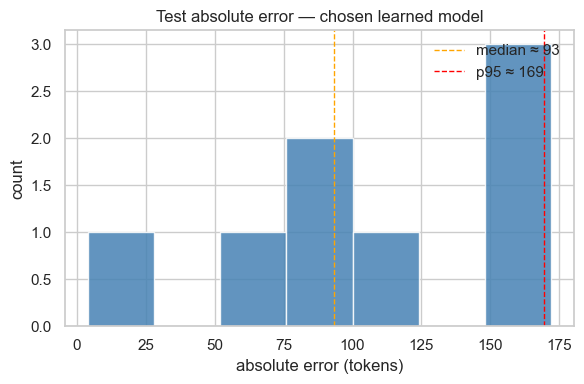

Typical error (chosen learned model B:OLS_best_subset): median 93.4 tokens; p95 169.5; max 172.0.

In [13]:
y_true_chosen, y_pred_chosen, chosen_label = resolve_chosen_predictions(
    summary_b=summary_b,
    res_a=res_a,
    res_b_ols=res_b_ols,
    res_b_ridge=res_b_ridge,
    res_b_enet=res_b_enet,
)

stats_chosen = abs_error_stats(y_true_chosen, y_pred_chosen)
med_c, p95_c, mx_c, n_c = stats_chosen['median'], stats_chosen['p95'], stats_chosen['max'], stats_chosen['n']

_ = plot_abs_error_hist(
    y_true_chosen, y_pred_chosen,
    bins=max(3, min(7, n_c)),
    title='Test absolute error — chosen learned model',
    show_refs=True,
    ref_values=(med_c, p95_c),
)

display(Markdown(
    f"Typical error (chosen learned model {chosen_label}): "
    f"median {med_c:.1f} tokens; p95 {p95_c:.1f}; max {mx_c:.1f}."
))


## Section 3 – Cross-Family Comparison and Decision

We now put everything on the same page: the three existing methods and the chosen learned model.

In [14]:
# Build a row for the chosen learned model consistent with evaluate_method_on_split outputs
learned_rows = []

if chosen_label.startswith('A') or summary_b.get('decision') == 'A':
    method_id_learned = f"A_single_feature({res_a['feature']})"
    y_true_learned = res_a['yte']
    y_pred_learned = res_a['pred']
elif chosen_label.startswith('B') or summary_b.get('decision') == 'B':
    bd = summary_b.get('B_details') or {}
    method_id_learned = f"B_{bd.get('model', 'unknown')}"
    y_true_learned = bd.get('yte')
    y_pred_learned = bd.get('pred')
else:
    method_id_learned = 'A_single_feature_fallback'
    y_true_learned = res_a['yte']
    y_pred_learned = res_a['pred']

y_true_learned = np.asarray(y_true_learned)
y_pred_learned = np.asarray(y_pred_learned)

test_mae_learned = float(np.mean(np.abs(y_true_learned - y_pred_learned)))
test_mbe_learned = float(np.mean(y_true_learned - y_pred_learned))
mape_learned = mape_filtered(y_true_learned, y_pred_learned, threshold=MAPE_THRESHOLD)
mape_learned_pct = None if mape_learned is None else float(mape_learned * 100.0)
stats_learned = abs_error_stats(y_true_learned, y_pred_learned)

learned_rows.append({
    'family': 'learned',
    'method_id': method_id_learned,
    'stage': 'learned_test',
    'test_mae': test_mae_learned,
    'test_mbe': test_mbe_learned,
    'mape_filtered_pct': mape_learned_pct,
    'abs_err_median': float(stats_learned['median']),
    'abs_err_p95': float(stats_learned['p95']),
    'abs_err_max': float(stats_learned['max']),
    'n': int(stats_learned['n']),
})

combined_rows = []
for row in existing_rows:
    combined_rows.append(row)
for row in learned_rows:
    combined_rows.append(row)

combined_table = build_comparison_table(combined_rows)

# Add relative improvement vs best existing method for the learned row
best_existing_mask = combined_table['family'] == 'existing'
if best_existing_mask.any():
    best_existing_mae = float(combined_table.loc[best_existing_mask, 'test_mae'].min())
else:
    best_existing_mae = np.nan

def _add_rel_improve(df, best_existing_mae):
    df = df.copy()
    df['improve_vs_best_existing_pct'] = np.nan
    if not np.isfinite(best_existing_mae):
        return df
    mask_learned = df['family'] == 'learned'
    df.loc[mask_learned, 'improve_vs_best_existing_pct'] = 100.0 * (best_existing_mae - df.loc[mask_learned, 'test_mae']) / best_existing_mae
    return df

combined_table = _add_rel_improve(combined_table, best_existing_mae)

display(Markdown('### Existing vs Learned Methods — Consolidated Test Performance'))
display(combined_table)


### Existing vs Learned Methods — Consolidated Test Performance

,family,method_id,stage,test_mae,test_mbe,mape_filtered_pct,abs_err_median,abs_err_p95,abs_err_max,n,improve_vs_best_existing_pct
3,learned,B_OLS_best_subset,learned_test,103.10365,46.673082,0.802198,93.436159,169.498922,171.952361,8,55.510831
1,existing,anth-ts_default,existing_test,231.75000,231.750000,1.809651,241.000000,339.850000,350.000000,8,NaN
2,existing,tiktoken_cl100k_base,existing_test,1499.62500,1499.625000,11.706587,1527.000000,1627.150000,1645.000000,8,NaN
0,existing,heuristic_3.5-runes-per-token,existing_test,2548.12500,2548.125000,19.868814,2548.500000,2971.528571,3108.428571,8,NaN


## Export Winning Model Coefficients (Learned Model)

In [15]:
rows_export = [
    {
        'approach': 'A_single_feature',
        'feature': res_a['feature'],
        'fit_intercept': res_a['fit_intercept'],
        'test_mae': res_a['test_mae'],
        'test_mbe': res_a['test_mbe'],
    }
]
if isinstance(summary_b.get('B_details'), dict):
    bd = summary_b['B_details']
    feat_str = ','.join(sorted(bd.get('coefs', {}).keys()))
    rows_export.append({
        'approach': f"B_{bd.get('model')}",
        'feature': feat_str if feat_str else 'bytes,runes,words,lines',
        'fit_intercept': True,
        'test_mae': bd.get('test_mae'),
        'test_mbe': bd.get('test_mbe'),
    })

MODEL_NAME = MODEL_NAME
try:
    decision = summary_b.get('decision') if isinstance(summary_b, dict) else None
    if decision == 'A' and isinstance(res_a, dict):
        out_path = export_single_feature(
            feature_type=res_a['feature'],
            a=res_a['coef_a'],
            b=res_a['intercept_b'],
            model=MODEL_NAME,
            scope='en-long-one-turn',
            estimator='LinearRegression',
            fit_intercept=res_a['fit_intercept'],
        )
        rel_export = Path('..') / 'models' / 'model_coefs.json'
        print({'exported': str(rel_export), 'type': 'single', 'feature': res_a['feature']})
    elif decision == 'B' and isinstance(summary_b.get('B_details'), dict):
        best_b = summary_b['B_details']
        flags = coef_sanity_checks(best_b.get('coefs', {}))
        if flags.get('negative_bytes') or flags.get('negative_runes'):
            print({'warning': 'coef sanity flags', **flags})

        feature_set = sorted(best_b.get('coefs', {}).keys())

        out_path = export_linear_multifeature(
            intercept=best_b['intercept'],
            coefs=best_b['coefs'],
            model=MODEL_NAME,
            scope='en-long-one-turn',
            estimator=best_b.get('model'),
            feature_set=feature_set,
        )
        rel_export = Path('..') / 'models' / 'model_coefs.json'
        print({'exported': str(rel_export), 'type': 'linear', 'model': best_b.get('model'), 'alpha': best_b.get('alpha', None), 'feature_set': feature_set})
    else:
        print({'export': 'skipped', 'reason': 'missing or invalid decision summary'})
except NameError as e:
    print({'export': 'skipped', 'reason': f'NameError: {e}'})


{'warning': 'coef sanity flags', 'negative_bytes': False, 'negative_runes': True, 'notes': ['runes coef negative']}
{'exported': '../models/model_coefs.json', 'type': 'linear', 'model': 'OLS_best_subset', 'alpha': None, 'feature_set': ['bytes', 'lines', 'runes']}


## Reproducibility

In [16]:
import platform

display(Markdown(
    f"""### Library versions:\n{'\n'.join([f'- {k}: {v}' for k, v in {"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__, "sklearn": sklearn.__version__}.items()])}"""
))


### Library versions:
- python: 3.13.5
- numpy: 2.3.4
- pandas: 2.3.3
- sklearn: 1.7.2